In [33]:
#Lillian Cunningham
#Class: 3474
#Section: 11am
#Assignment 3 - Graphs

In [34]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
#Step 1
#Art Institute of Chicago API: https://api.artic.edu/docs/#quick-start
#Endpoint Documentation: https://api.artic.edu/api/v1/artworks
#Fields used:
#date_start (Quantitative, continuous)
#date_end (Quantitative, continuous)
#artist_title (Qualitative, nominal)
#medium_display (Qualitative, nominal)
#artwork_type_title (Qualitative, nominal)


In [36]:
#Step 2
url = "https://api.artic.edu/api/v1/artworks"
all_records = []

for page in range(1, 4):
  params = {
      "page": page,
      "limit": 100,
      "fields": "date_start,date_end,artist_title,artwork_type_title,medium_display"
  }
  response = requests.get(url, params=params, timeout=15)

  if response.status_code !=200:
    print(f"API request failed ")
  else:
    data = response.json()
    all_records.extend(data["data"])

In [37]:
#Step 3
df = pd.DataFrame(all_records)
df = df[["date_start", "date_end", "artist_title", "artwork_type_title", "medium_display"]]
print("\nDataFrame shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


DataFrame shape: (300, 5)

First 5 rows:
   date_start  date_end artist_title artwork_type_title  \
0      -100.0     500.0        Moche           Ceramics   
1      -100.0     500.0        Moche          Metalwork   
2      -650.0    -150.0      Paracas           Ceramics   
3      1200.0    1450.0        Chimú          Metalwork   
4      -650.0    -150.0      Paracas           Ceramics   

                           medium_display  
0                     Ceramic and pigment  
1  Copper, mussel shell, mica, and pyrite  
2    Ceramic with resinous postfire paint  
3                                    Gold  
4                     Ceramic and pigment  


In [38]:
#Step 4
initial_description = df.describe(include ="all")
print(initial_description)

df["date_start"]         = pd.to_numeric(df["date_start"], errors="coerce")
df["date_end"]           = pd.to_numeric(df["date_end"],   errors="coerce")
df["artist_title"]       = df["artist_title"].astype("category")
df["artwork_type_title"] = df["artwork_type_title"].astype("category")
df["medium_display"]     = df["medium_display"].astype("category")

df = df.dropna(subset=["date_start", "date_end"])
df["date_start"] = df["date_start"].astype(int)
df["date_end"]   = df["date_end"].astype(int)

print("\nCorrected dtypes:")
print(df.dtypes)

         date_start     date_end artist_title artwork_type_title  \
count    297.000000   297.000000          284                300   
unique          NaN          NaN           32                 10   
top             NaN          NaN        Moche           Ceramics   
freq            NaN          NaN          164                206   
mean     490.289562   897.673401          NaN                NaN   
std      930.918486   689.457007          NaN                NaN   
min     -650.000000  -150.000000          NaN                NaN   
25%     -100.000000   500.000000          NaN                NaN   
50%     -100.000000   500.000000          NaN                NaN   
75%     1770.000000  1841.000000          NaN                NaN   
max     2016.000000  2016.000000          NaN                NaN   

             medium_display  
count                   298  
unique                   71  
top     Ceramic and pigment  
freq                    184  
mean                    NaN  
std

In [39]:
#Step 5
final_description = df.describe(include="all")
print(final_description)

'''
date_start is the year the artwork was started.
date_end is the year the artwork was completed.
artist_title is the artist or workshop that made the artwork.
artwork_type_title is what type of artwork it is.
medium_display is the description of what materials were used to make the artwork.
'''

'''
date_start: The mean shows us that the start year for artworks is around the 18th and 19th centuries. This allows us to interpret that
            the institute's artwork is mostly composed of modern works. The min and max values show that the isnitutes collection ranges
            from very ancient artworks to modern artworks as recent as 2016.
date_end: This is very similar to the date_start, which makes sense because most of the artwork was completed very soon after it was started.
          The mean and median are also close together, which we can suggest a symmetric distribution with a few outliers.
'''

         date_start     date_end artist_title artwork_type_title  \
count    297.000000   297.000000          283                297   
unique          NaN          NaN           31                 10   
top             NaN          NaN        Moche           Ceramics   
freq            NaN          NaN          164                206   
mean     490.289562   897.673401          NaN                NaN   
std      930.918486   689.457007          NaN                NaN   
min     -650.000000  -150.000000          NaN                NaN   
25%     -100.000000   500.000000          NaN                NaN   
50%     -100.000000   500.000000          NaN                NaN   
75%     1770.000000  1841.000000          NaN                NaN   
max     2016.000000  2016.000000          NaN                NaN   

             medium_display  
count                   295  
unique                   69  
top     Ceramic and pigment  
freq                    184  
mean                    NaN  
std

"\ndate_start: The mean shows us that the start year for artworks is around the 18th and 19th centuries. This allows us to interpret that \n            the institute's artwork is mostly composed of modern works. The min and max values show that the isnitutes collection ranges \n            from very ancient artworks to modern artworks as recent as 2016. \ndate_end: This is very similar to the date_start, which makes sense because most of the artwork was completed very soon after it was started. \n          The mean and median are also close together, which we can suggest a symmetric distribution with a few outliers. \n"

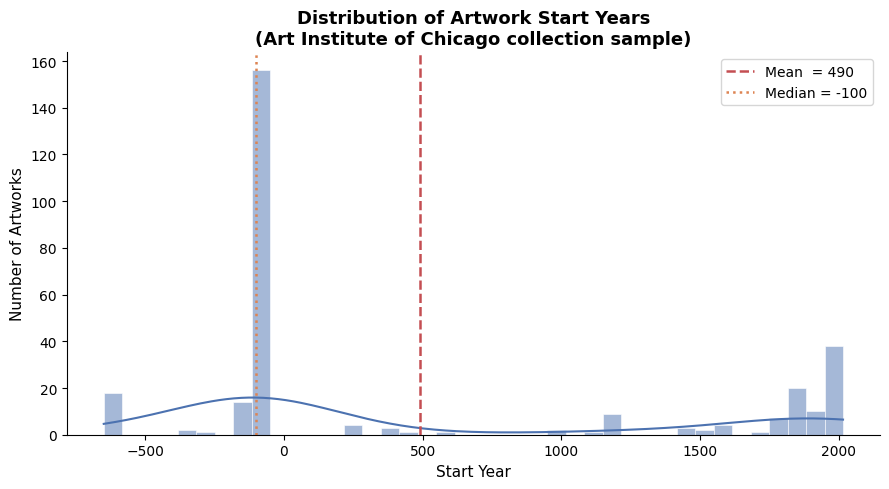

'\nThis histogram shows the start years of artworks at the Art Institute of Chicago. \nIt shows that the Institute has more artworks concentrated in earlier historical periods but the \ndistribution is right-skewed due to the modern works that have been added in recent years. \n\n'

In [40]:
#Step 6
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["date_start"], bins=40, kde=True,
             color="#4C72B0", edgecolor="white", linewidth=0.4, ax=ax)
ax.axvline(df["date_start"].mean(),   color="#C44E52", linestyle="--", linewidth=1.8,
           label=f"Mean  = {df['date_start'].mean():.0f}")
ax.axvline(df["date_start"].median(), color="#DD8452", linestyle=":",  linewidth=1.8,
           label=f"Median = {df['date_start'].median():.0f}")
ax.set_title("Distribution of Artwork Start Years\n(Art Institute of Chicago collection sample)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Start Year", fontsize=11)
ax.set_ylabel("Number of Artworks", fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig("cunningham_univariate.png", dpi=150)
plt.show()

#Step 6a
#With a comment, explain what the graph represents.
'''
This histogram shows the start years of artworks at the Art Institute of Chicago.
It shows that the Institute has more artworks concentrated in earlier historical periods but the
distribution is right-skewed due to the modern works that have been added in recent years.

'''


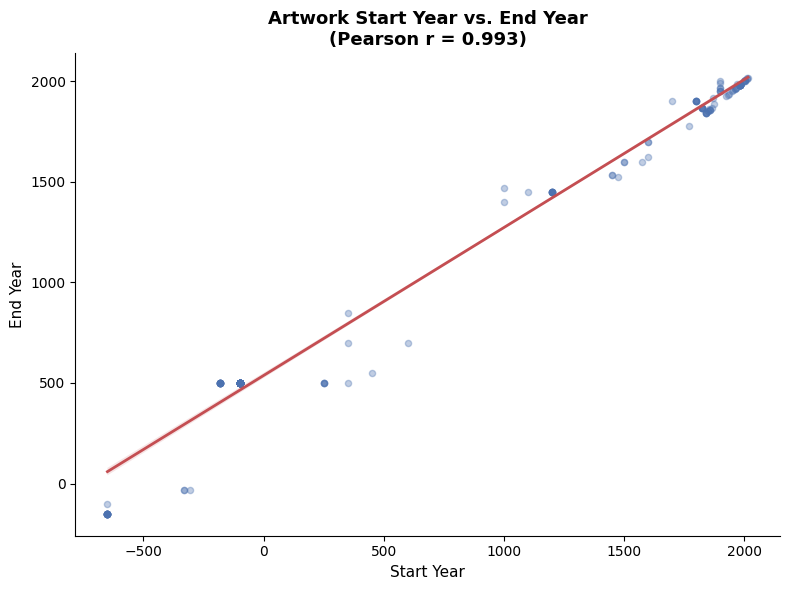

'\nThis scatter plot represents the relationship between when artworks were started vs. when they were completed. We can see that artowkrs that start \nlater tend to end later. The points that lie close to the line suggest that many artworks were completed shortly after they were started. \nThere are some outliers in the graph which can be seen thatshow that some artworks took many years\nto complete. This graph also shows a positive linear relationship between the start year and end year of the artworks. \n\n'

In [41]:
#Step 7
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=df,
    x="date_start", y="date_end",
    scatter_kws={"alpha": 0.35, "s": 20, "color": "#4C72B0"},
    line_kws={"color": "#C44E52", "linewidth": 2},
    ax=ax,
)
corr = df["date_start"].corr(df["date_end"])
ax.set_title(f"Artwork Start Year vs. End Year\n(Pearson r = {corr:.3f})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Start Year", fontsize=11)
ax.set_ylabel("End Year", fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig("cunningham_bivariant.png", dpi=150)
plt.show()

#Step 7a
'''
This scatter plot represents the relationship between when artworks were started vs. when they were completed. We can see that artowkrs that start
later tend to end later. The points that lie close to the line suggest that many artworks were completed shortly after they were started.
There are some outliers in the graph which can be seen thatshow that some artworks took many years
to complete. This graph also shows a positive linear relationship between the start year and end year of the artworks.

'''

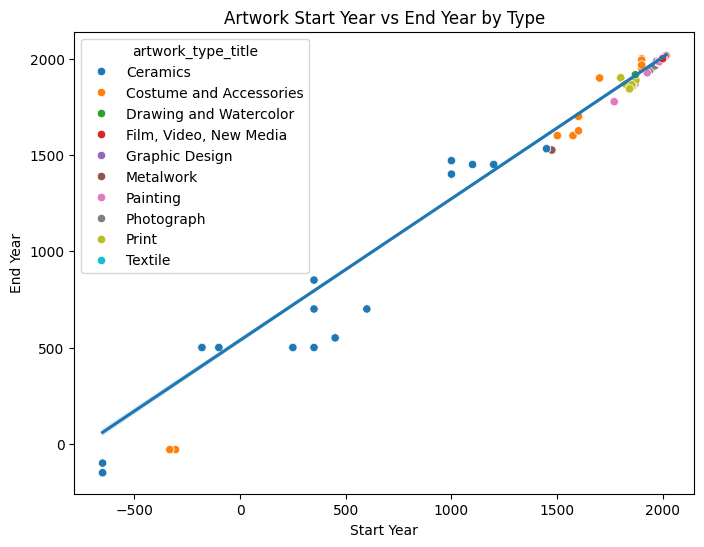

'\nThis graph represents the same start year and end year line we saw in the previous graph but instead with dots on \nit that represent the class or type of artwork. We can see that more modern forms of artwork like film and photographs cluster at the top\nof the graph near current dates, while ceramics tend to be seen in more ancient times. Drawings and prints can be seen ranging all \nacross different time periods. We can also see that some sculptures and ceramics that represent outliers took longer to finish. \n'

In [42]:
#Step 8
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="date_start",
    y="date_end",
    hue="artwork_type_title",
    ax=ax
)
sns.regplot(
    data=df,
    x="date_start",
    y="date_end",
    scatter=False,
    ax=ax
)

ax.set_xlabel("Start Year")
ax.set_ylabel("End Year")
ax.set_title("Artwork Start Year vs End Year by Type")

plt.savefig("cunningham_multivariate.png", dpi=150)
plt.show()

#Step 8a
'''
This graph represents the same start year and end year line we saw in the previous graph but instead with dots on
it that represent the class or type of artwork. We can see that more modern forms of artwork like film and photographs cluster at the top
of the graph near current dates, while ceramics tend to be seen in more ancient times. Drawings and prints can be seen ranging all
across different time periods. We can also see that some sculptures and ceramics that represent outliers took longer to finish.
'''

In [43]:
#Step 9
stats_text = """

date_start is the year the artwork was started.
date_end is the year the artwork was completed.
artist_title is the artist or workshop that made the artwork.
artwork_type_title is what type of artwork it is.
medium_display is the description of what materials were used to make the artwork.

date_start: The mean shows us that the start year for artworks is around the 18th and 19th centuries. This allows us to interpret that
            the institute's artwork is mostly composed of modern works. The min and max values show that the isnitutes collection ranges
            from very ancient artworks to modern artworks as recent as 2016.
date_end: This is very similar to the date_start, which makes sense because most of the artwork was completed very soon after it was started.
          The mean and median are also close together, which we can suggest a symmetric distribution with a few outliers.

This histogram shows the start years of artworks at the Art Institute of Chicago.
It shows that the Institute has more artworks concentrated in earlier historical periods but the
distribution is right-skewed due to the modern works that have been added in recent years.

This scatter plot represents the relationship between when artworks were started vs. when they were completed. We can see that artowkrs that start
later tend to end later. The points that lie close to the line suggest that many artworks were completed shortly after they were started.
There are some outliers in the graph which can be seen thatshow that some artworks took many years
to complete. This graph also shows a positive linear relationship between the start year and end year of the artworks.

This graph represents the same start year and end year line we saw in the previous graph but instead with dots on
it that represent the class or type of artwork. We can see that more modern forms of artwork like film and photographs cluster at the top
of the graph near current dates, while ceramics tend to be seen in more ancient times. Drawings and prints can be seen ranging all
across different time periods. We can also see that some sculptures and ceramics that represent outliers took longer to finish.

"""

# 2. Add the describe() output to the string
stats_text += final_description.to_string()

# 3. Open a file and write the string to it
with open("cunningham_stats.txt", "w", encoding="utf-8") as f:
    f.write(stats_text)